In [20]:
import os
import gzip
import json
import collections
import pandas as pd
import subprocess
import shutil
import sys
import bisect
import numpy as np

# -----------------------
# Configuration
# -----------------------
TEST_SAMPLES_CSV = "training_processed_metadata.csv"
THRESHOLDS_JSON = "training_results/best_thresholds.json"
OUT_DIR = "training_results"

# Paths to your blacklists (Make sure these match your filenames!)
BLACKLIST_BED = "../../resources/master_blacklist.bed"  
ARTEFACT_GENES_BED = "../../resources/master_blacklist.bed" 

# Constants
GENOME_SIZE = 6.4e9
R_CORD = 2e-8

# -----------------------
# BED Lookup Logic (With Chromosome Name Fix)
# -----------------------
class BedLookup:
    def __init__(self, bed_path, name):
        self.intervals = {} 
        self.name = name
        self._load_bed(bed_path)

    def _load_bed(self, bed_path):
        if not os.path.exists(bed_path):
            print(f"[WARN] BED file not found: {bed_path}. {self.name} filter will do nothing.", file=sys.stderr)
            return

        print(f"[INFO] Loading {self.name} from {bed_path}...")
        count = 0
        with open(bed_path, 'r') as f:
            for line in f:
                if line.startswith('#') or not line.strip():
                    continue
                parts = line.strip().split()
                if len(parts) < 3:
                    continue
                chrom = parts[0]
                start, end = int(parts[1]), int(parts[2])
                
                if chrom not in self.intervals:
                    self.intervals[chrom] = []
                self.intervals[chrom].append((start, end))
                count += 1
        
        # Sort intervals for binary search
        for chrom in self.intervals:
            self.intervals[chrom].sort(key=lambda x: x[0])
        print(f"[INFO] Loaded {count} regions for {self.name}.")

    def is_overlapped(self, chrom, pos):
        # 1. Try exact match (e.g., "1" == "1")
        if chrom in self.intervals:
            regions = self.intervals[chrom]
        # 2. Try adding 'chr' (e.g., "1" -> "chr1")
        elif f"chr{chrom}" in self.intervals:
            regions = self.intervals[f"chr{chrom}"]
        # 3. Try removing 'chr' (e.g., "chr1" -> "1")
        elif chrom.startswith("chr") and chrom[3:] in self.intervals:
            regions = self.intervals[chrom[3:]]
        else:
            return False
        
        # Binary search
        query_idx = pos - 1 
        idx = bisect.bisect_right(regions, (query_idx, float('inf')))
        
        for i in range(max(0, idx - 1), -1, -1):
            start, end = regions[i]
            if end <= query_idx:
                break 
            if start <= query_idx < end:
                return True
        return False

# -----------------------
# Helper Functions
# -----------------------
def safe_float(x, default=0.0):
    try:
        return float(x)
    except (ValueError, TypeError):
        return default

def safe_int(x, default=0):
    try:
        return int(float(x))
    except (ValueError, TypeError):
        return default

def parse_info(info_str):
    info_dict = {}
    if not info_str or info_str == ".":
        return info_dict
    for item in info_str.split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            info_dict[k] = v
        else:
            info_dict[item] = "Yes"
    return info_dict

def check_dependencies():
    return shutil.which("bgzip") is not None and shutil.which("tabix") is not None

def get_expected_rate(sample_type, age):
    st = sample_type.lower()
    age = float(age) if pd.notna(age) else 0.0
    if "cord" in st:
        return R_CORD
    elif "pbmc" in st:
        return (16 * age + 105) / GENOME_SIZE
    else:
        return (22 * age + 164) / GENOME_SIZE

# -----------------------
# Filtering Logic
# -----------------------
def apply_filters(info, thresholds, pon_flags):
    """
    Apply tuned filters to a single variant.
    Note: Blacklist checks happen BEFORE this function is called.
    """
    # 1. Extract & Type Convert
    n_total_dcs = safe_int(info.get("N_TOTAL", 0))
    n_total_sscs = safe_int(info.get("N_TOTAL_SSCS", n_total_dcs))
    if n_total_sscs <= 0: n_total_sscs = n_total_dcs
    n_alt_sscs = safe_int(info.get("N_ALT_SSCS", 0))

    # Metrics
    asxs = safe_float(info.get("AVG_ALT_ASXS", 0.0))
    mean_mapq = safe_float(info.get("MEAN_ALT_MAPQ", 0.0))
    mean_baseq = safe_float(info.get("MEAN_ALT_BASEQ", 0.0))
    dist_to_indel = safe_int(info.get("DIST_TO_INDEL", -1))
    homopolymer_len = safe_int(info.get("HOMOPOLYMER_LEN", 0))
    gc_content = safe_float(info.get("GC_CONTENT", 0.5))
    strand_bias = safe_float(info.get("STRAND_BIAS_SSCS", 0.5))
    rp_sd = safe_float(info.get("RP_SD_SSCS", 0.0))
    rp_med = safe_float(info.get("RP_MED_SSCS", 0.5))
    depth_percentile = safe_int(info.get("DEPTH_PERCENTILE", 50))
    avg_read_pos = safe_float(info.get("AVG_READ_POSITION", 75.0))
    
    # New Metrics
    variants_20bp = safe_int(info.get("VARIANTS_20BP", 0))
    variants_250bp = safe_int(info.get("VARIANTS_250BP", 0))
    median_dist_softclip = safe_int(info.get("MEDIAN_DIST_TO_SOFTCLIP", 1000))
    ref_entropy = safe_float(info.get("REF_ENTROPY_40BP", 2.0))
    avg_alt_softclip = safe_float(info.get("AVG_ALT_SOFTCLIP", 0.0))
    avg_alt_n_count = safe_float(info.get("AVG_ALT_N_COUNT", 0.0))
    avg_alt_nm = safe_float(info.get("AVG_ALT_NM", 0.0))
    mean_insert = safe_float(info.get("MEAN_INSERT", 200.0))
    avg_altread_vars = safe_float(info.get("AVG_ALTREAD_VARIANTS", 0.0))

    # Flags
    in_cord_pon = info.get("IN_CB_PON", "No")
    in_gnomad = info.get("IN_GNOMAD_COMMON", "No")
    in_encode = info.get("IN_ENCODE_BLACKLIST", "No")
    in_repeatmasker = info.get("IN_REPEATMASKER", "No")

    # VAFs
    vaf_sscs = n_alt_sscs / n_total_sscs if n_total_sscs > 0 else 0.0
    vaf_dcs = safe_int(info.get("N_ALT", 0)) / n_total_dcs if n_total_dcs > 0 else 0.0

    # 2. Logic
    if n_alt_sscs <= 0: return False, "HARD_N_ALT_SSCS"
    if in_encode == "Yes": return False, "HARD_ENCODE_BLACKLIST"
    if in_repeatmasker == "Yes": return False, "HARD_REPEATMASKER"

    # OxoG / Read Pos Hard Filter
    if avg_read_pos < 4 or avg_read_pos > 138: return False, "HARD_READ_POS_EDGE"

    if pon_flags.get("use_cord_pon", False) and in_cord_pon == "Yes":
        return False, "FAIL_CORD_PON"

    if n_total_dcs < thresholds["n_total_min"]: return False, "FAIL_MIN_DEPTH"
    if depth_percentile > thresholds["depth_percentile_max"]: return False, "FAIL_DEPTH_PERCENTILE"

    if asxs < thresholds["asxs_min"]: return False, "FAIL_ASXS"
    if mean_mapq < thresholds["mean_mapq_min"]: return False, "FAIL_MAPQ"
    if mean_baseq < thresholds["mean_baseq_min"]: return False, "FAIL_BASEQ"
    if dist_to_indel != -1 and dist_to_indel < thresholds["dist_to_indel_min"]: return False, "FAIL_DIST_TO_INDEL"

    if variants_20bp > thresholds["variants_20bp_max"]: return False, "FAIL_VARIANTS_20BP"
    if variants_250bp > thresholds["variants_250bp_max"]: return False, "FAIL_VARIANTS_250BP"
    if ref_entropy < thresholds["ref_entropy_min"]: return False, "FAIL_REF_ENTROPY"
    if avg_alt_softclip > thresholds["avg_alt_softclip_max"]: return False, "FAIL_AVG_ALT_SOFTCLIP"
    if median_dist_softclip < thresholds["dist_to_softclip_min"]: return False, "FAIL_DIST_TO_SOFTCLIP"
    if avg_alt_n_count > thresholds["avg_alt_n_count_max"]: return False, "FAIL_AVG_ALT_N_COUNT"
    if avg_alt_nm > thresholds["avg_alt_nm_max"]: return False, "FAIL_AVG_ALT_NM"
    if mean_insert > thresholds["mean_insert_max"]: return False, "FAIL_MEAN_INSERT"

    if gc_content < thresholds["gc_content_min"] or gc_content > thresholds["gc_content_max"]: return False, "FAIL_GC_CONTENT"
    if homopolymer_len > thresholds["homopolymer_len_max"]: return False, "FAIL_HOMOPOLYMER"

    if n_alt_sscs >= thresholds["strand_bias_n_alt_min"]:
        if strand_bias < thresholds["strand_bias_min"] or strand_bias > thresholds["strand_bias_max"]:
            return False, "FAIL_STRAND_BIAS"

    if n_alt_sscs >= thresholds["rp_sd_min_alt"]:
        if rp_sd < thresholds["rp_sd_min"]: return False, "FAIL_RP_SD"
    if rp_med < thresholds["rp_med_min"] or rp_med > thresholds["rp_med_max"]: return False, "FAIL_RP_MED"

    is_high_avg = avg_altread_vars > thresholds["avg_altread_variants_max"]
    is_high_cond = (avg_altread_vars > thresholds["avg_altread_variants_max_for_high_vaf"]) and \
                   (vaf_dcs > thresholds["avg_altread_high_vaf_cutoff"])
    if is_high_avg or is_high_cond: return False, "FAIL_AVG_ALTREAD_VARIANTS"

    if vaf_sscs > thresholds["germline_vaf_max"]: return False, "FAIL_GERMLINE_VAF"
    if (vaf_sscs > thresholds["gnomad_vaf_cutoff"]) and (in_gnomad == "Yes"):
        return False, "FAIL_GNOMAD_COMMON"

    return True, None

# -----------------------
# Main Execution
# -----------------------
os.makedirs(OUT_DIR, exist_ok=True)
has_htslib = check_dependencies()

# 1. Load Blacklists
print("[INFO] Initializing Blacklists...")
cluster_lookup = BedLookup(BLACKLIST_BED, "Cluster Blacklist")
artefact_lookup = BedLookup(ARTEFACT_GENES_BED, "Artefact Gene Blacklist")

# 2. Load Thresholds
if not os.path.exists(THRESHOLDS_JSON):
    print(f"[ERROR] Thresholds file not found: {THRESHOLDS_JSON}")
else:
    with open(THRESHOLDS_JSON) as f:
        data = json.load(f)
        thresholds = data["thresholds"]
        pon_flags = data.get("pon_flags", {})
    print("[INFO] Thresholds loaded.")

    if not os.path.exists(TEST_SAMPLES_CSV):
         print(f"[ERROR] Test samples CSV not found: {TEST_SAMPLES_CSV}")
    else:
        df_samples = pd.read_csv(TEST_SAMPLES_CSV)
        print(f"[INFO] Processing {len(df_samples)} test samples...")

        results_data = []
        all_fail_reasons = []

        for idx, s in df_samples.iterrows():
            print(f"  -> {s.sample_id}", end="\r")
            
            input_basename = os.path.basename(s.vcf_path).replace(".vcf", "").replace(".gz", "")
            out_vcf_path = os.path.join(OUT_DIR, f"{s.sample_id}_{input_basename}.filtered.vcf")
            
            if not os.path.exists(s.vcf_path):
                print(f"\n[WARN] VCF not found: {s.vcf_path}")
                continue

            openf = gzip.open if s.vcf_path.endswith(".gz") else open
            n_pass = 0
            
            try:
                with openf(s.vcf_path, "rt") as fin, open(out_vcf_path, "w") as fout:
                    for line in fin:
                        if line.startswith("#"):
                            fout.write(line)
                            continue
                        
                        fields = line.strip().split("\t")
                        if len(fields) < 8: continue
                        
                        # --- CRITICAL: Coordinate Check ---
                        chrom = fields[0]
                        pos = int(fields[1])
                        
                        # Check Cluster Blacklist
                        if cluster_lookup.is_overlapped(chrom, pos):
                            all_fail_reasons.append("FAIL_CLUSTER_BLACKLIST")
                            continue # Skip variant
                        
                        # Check Artefact Gene Blacklist (OR/KRTAP/MUC/etc)
                        if artefact_lookup.is_overlapped(chrom, pos):
                            all_fail_reasons.append("FAIL_ARTEFACT_BLACKLIST")
                            continue # Skip variant
                        # -----------------------------------
                        
                        info = parse_info(fields[7])
                        passed, reason = apply_filters(info, thresholds, pon_flags)
                        
                        if passed:
                            n_pass += 1
                            fout.write(line)
                        else:
                            all_fail_reasons.append(reason)
            except Exception as e:
                print(f"\n[ERROR] Failed on {s.sample_id}: {e}")
                continue

            # Compression
            if has_htslib:
                try:
                    subprocess.run(["bgzip", "-f", out_vcf_path], check=True, stderr=subprocess.DEVNULL)
                    subprocess.run(["tabix", "-p", "vcf", out_vcf_path + ".gz"], check=True, stderr=subprocess.DEVNULL)
                except:
                    pass
            
            # Data Collection
            sample_type = s.sample_type if "sample_type" in s else "T_cells"
            age = s.age if "age" in s else 0.0
            bases = float(s["callable_sequenced_bases_padded"])
            
            exp_rate = get_expected_rate(sample_type, age)
            exp_count = exp_rate * bases
            
            results_data.append({
                "sample_id": s.sample_id,
                "sample_type": sample_type,
                "age": age,
                "bases": bases,
                "observed": n_pass,
                "expected": exp_count
            })

        print("\n[INFO] Filtering complete.")

        # 3. Save Summary
        res_df = pd.DataFrame(results_data)
        res_df.to_csv(os.path.join(OUT_DIR, "test_summary.csv"), index=False)
        
        # Save Failure Counts
        reason_counts = collections.Counter(all_fail_reasons)
        fail_df = pd.DataFrame(reason_counts.items(), columns=["Reason", "Count"]).sort_values("Count", ascending=False)
        fail_df.to_csv(os.path.join(OUT_DIR, "filter_failure_counts.csv"), index=False)

        print("-" * 30)
        print(f"Results saved to: {OUT_DIR}")
        print("-" * 30)

[INFO] Initializing Blacklists...
[INFO] Loading Cluster Blacklist from ../../resources/master_blacklist.bed...
[INFO] Loaded 4208652 regions for Cluster Blacklist.
[INFO] Loading Artefact Gene Blacklist from ../../resources/master_blacklist.bed...
[INFO] Loaded 4208652 regions for Artefact Gene Blacklist.
[INFO] Thresholds loaded.
[INFO] Processing 18 test samples...
  -> LEGACY_I6_H6
[INFO] Filtering complete.
------------------------------
Results saved to: training_results
------------------------------


[INFO] Poisson Deviance on Test Set: 8111.9049
[INFO] Plot saved to: CUH832_results/test_observed_vs_expected_plot.png


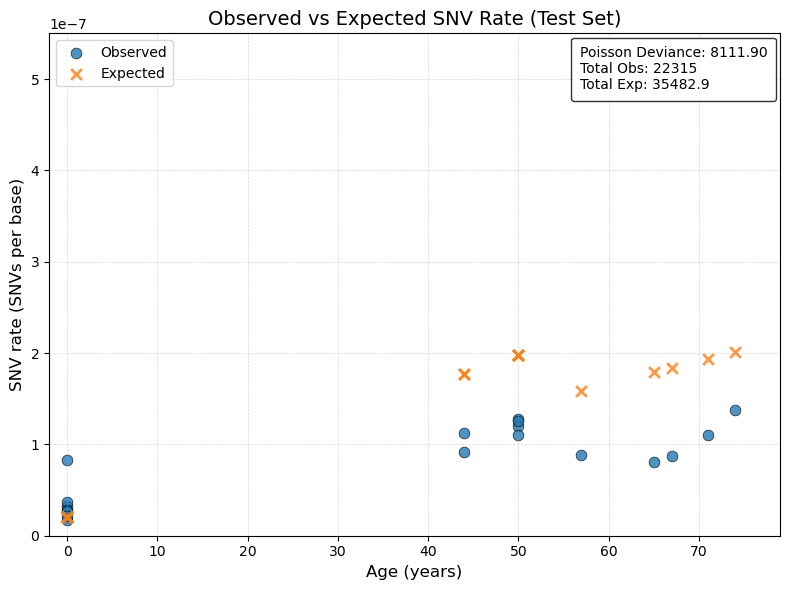

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.offsetbox import AnchoredText

# -----------------------
# Configuration
# -----------------------
# Path to the CSV generated by the test filtering step
CSV_PATH = "CUH832_results/test_summary.csv"
OUTPUT_PNG = "CUH832_results/test_observed_vs_expected_plot.png"
EPS = 1e-15

# -----------------------
# Metric Calculation
# -----------------------
def poisson_deviance(y_arr, lam_arr):
    """
    Calculates Poisson Deviance between observed (y) and expected (lambda).
    Formula: 2 * sum( y * log(y / lambda) - (y - lambda) )
    """
    y = np.asarray(y_arr, dtype=float)
    lam = np.asarray(lam_arr, dtype=float) + EPS
    
    with np.errstate(divide='ignore', invalid='ignore'):
        log_term = np.log(y / lam)
        term1 = np.where(y > 0, y * log_term, 0.0)
    
    dev = 2.0 * (term1 - (y - lam))
    return float(np.sum(dev))

# Check if file exists
if not os.path.exists(CSV_PATH):
    print(f"[ERROR] Could not find {CSV_PATH}. Please run the test filtering cell first.")
else:
    # Load table
    df = pd.read_csv(CSV_PATH)

    # Convert data arrays
    ages = df["age"].values
    bases = df["bases"].values
    observed = df["observed"].values
    expected = df["expected"].values
    
    # Calculate SNV rates per base
    obs_rate = observed / bases
    exp_rate = expected / bases

    # Calculate Deviance
    deviance = poisson_deviance(observed, expected)
    total_obs = np.sum(observed)
    total_exp = np.sum(expected)

    # -----------------------
    # Plotting
    # -----------------------
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot Observed (Blue circles)
    ax.scatter(ages, obs_rate, label="Observed", color="#1f77b4", alpha=0.8, marker="o", s=60, edgecolors='k', linewidth=0.5)

    # Plot Expected (Orange crosses)
    ax.scatter(ages, exp_rate, label="Expected", color="#ff7f0e", alpha=0.8, marker="x", s=60, linewidth=2)

    # Styling
    ax.set_xlabel("Age (years)", fontsize=12)
    ax.set_ylabel("SNV rate (SNVs per base)", fontsize=12)
    
    # Handle X-limits (pad slightly around min/max age)
    valid_ages = ages[~np.isnan(ages)]
    if len(valid_ages) > 0:
        ax.set_xlim(min(valid_ages) - 2, max(valid_ages) + 5)
    else:
        ax.set_xlim(-2, 100)

    # Hardcoded Y-limits (Same as training plot for consistency)
    ax.set_ylim(0, 5.5e-7)
    
    ax.set_title("Observed vs Expected SNV Rate (Test Set)", fontsize=14)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Add Stats Box (Deviance)
    stats_text = (f"Poisson Deviance: {deviance:.2f}\n"
                  f"Total Obs: {int(total_obs)}\n"
                  f"Total Exp: {total_exp:.1f}")
    
    at = AnchoredText(stats_text, prop=dict(size=10), frameon=True, loc='upper right')
    at.patch.set_boxstyle("round,pad=0.2,rounding_size=0.2")
    at.patch.set_alpha(0.8)
    ax.add_artist(at)

    # Legend
    ax.legend(loc='upper left', frameon=True, fontsize=10)

    plt.tight_layout()
    
    # Save and Show
    plt.savefig(OUTPUT_PNG, dpi=150)
    print(f"[INFO] Poisson Deviance on Test Set: {deviance:.4f}")
    print(f"[INFO] Plot saved to: {OUTPUT_PNG}")
    plt.show()

[INFO] Train Cord Rate: 3.12e-08 (Obs: 1241)
[INFO] Test Cord Rate:  2.86e-08 (Obs: 2383)
[INFO] Reference Rate:  2.00e-08
[INFO] Plot saved to: ./cord_blood_snv_comparison.png


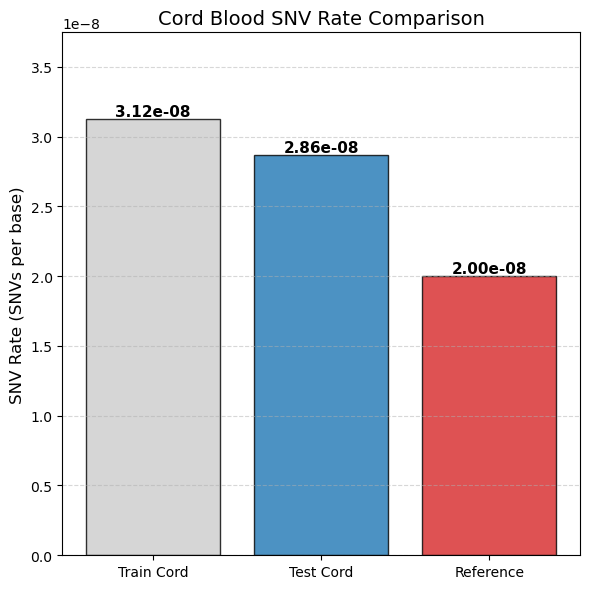

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------
# Configuration
# -----------------------
TRAIN_CSV = "training_results/observed_expected.csv"
TEST_CSV = "CUH832_results/test_summary.csv"
OUTPUT_PNG = "./cord_blood_snv_comparison.png"
REFERENCE_RATE = 2e-8

def get_cord_blood_rate(csv_path):
    """
    Loads CSV, filters for age == 0 (Cord Blood), 
    and calculates aggregate SNV rate.
    """
    if not os.path.exists(csv_path):
        print(f"[WARNING] File not found: {csv_path}")
        return 0.0, 0  # Return 0 rate and 0 count
        
    df = pd.read_csv(csv_path)
    
    # Filter for Cord Blood (Age = 0)
    # Using a small epsilon or direct comparison depending on data precision
    cord_data = df[np.isclose(df["age"], 0, atol=1e-5)]
    
    if cord_data.empty:
        print(f"[WARNING] No Cord Blood (age=0) data found in {csv_path}")
        return 0.0, 0
    
    total_obs = cord_data["observed"].sum()
    total_bases = cord_data["bases"].sum()
    
    if total_bases == 0:
        return 0.0, 0
        
    return total_obs / total_bases, total_obs

# -----------------------
# Main Execution
# -----------------------
# 1. Get Rates
train_rate, train_obs_count = get_cord_blood_rate(TRAIN_CSV)
test_rate, test_obs_count = get_cord_blood_rate(TEST_CSV)

# 2. Prepare Data for Plotting
labels = ['Train Cord', 'Test Cord', 'Reference']
rates = [train_rate, test_rate, REFERENCE_RATE]
colors = ['#cccccc', '#1f77b4', '#d62728']  # Grey (Train), Blue (Test), Red (Ref)

# 3. Plotting
fig, ax = plt.subplots(figsize=(6, 6))

# Create Bars
bars = ax.bar(labels, rates, color=colors, edgecolor='k', alpha=0.8)

# 4. Styling
ax.set_ylabel("SNV Rate (SNVs per base)", fontsize=12)
ax.set_title("Cord Blood SNV Rate Comparison", fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2e}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Adjust Y-limit to fit labels
ax.set_ylim(0, max(rates) * 1.2)

plt.tight_layout()

# 5. Save and Show
plt.savefig(OUTPUT_PNG, dpi=150)
print(f"[INFO] Train Cord Rate: {train_rate:.2e} (Obs: {int(train_obs_count)})")
print(f"[INFO] Test Cord Rate:  {test_rate:.2e} (Obs: {int(test_obs_count)})")
print(f"[INFO] Reference Rate:  {REFERENCE_RATE:.2e}")
print(f"[INFO] Plot saved to: {OUTPUT_PNG}")
plt.show()

[INFO] Test Deviance: 8111.9049
[INFO] Plot saved to: ./test_vs_train_overlay_plot.png


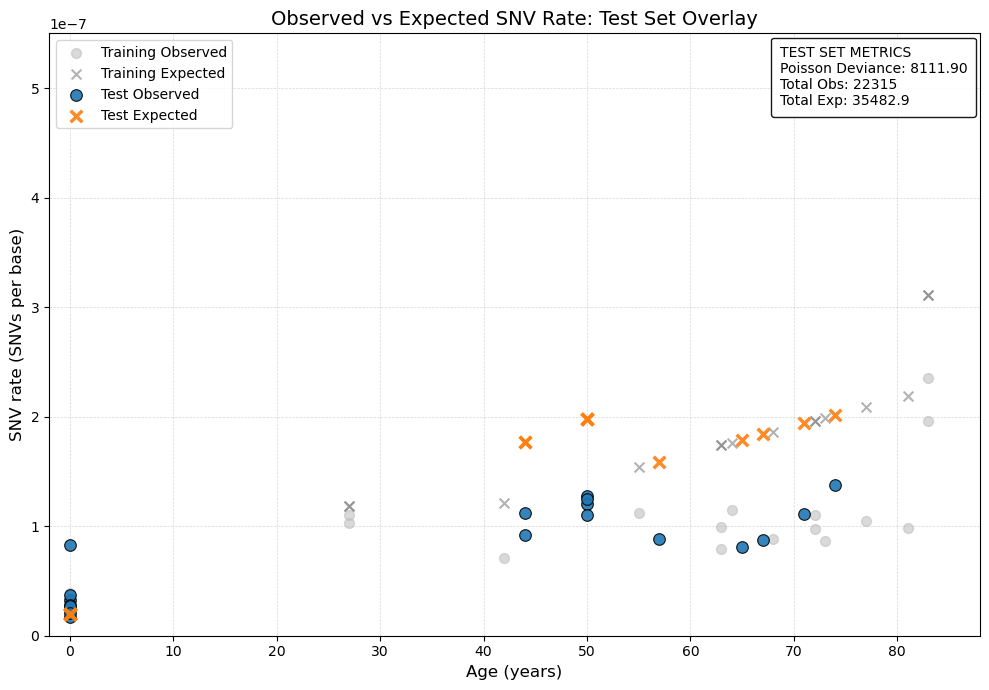

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.offsetbox import AnchoredText

# -----------------------
# Configuration
# -----------------------
# Paths to your results
TEST_CSV_PATH = "CUH832_results/test_summary.csv"           # Generated by test/evaluation step
TRAIN_CSV_PATH = "training_results/observed_expected.csv" # Generated by training step

OUTPUT_PNG = "./test_vs_train_overlay_plot.png"
EPS = 1e-15

# -----------------------
# Metric Calculation Helper
# -----------------------
def poisson_deviance(y_arr, lam_arr):
    """
    Calculates Poisson Deviance between observed (y) and expected (lambda).
    Formula: 2 * sum( y * log(y / lambda) - (y - lambda) )
    """
    y = np.asarray(y_arr, dtype=float)
    lam = np.asarray(lam_arr, dtype=float) + EPS
    
    with np.errstate(divide='ignore', invalid='ignore'):
        log_term = np.log(y / lam)
        term1 = np.where(y > 0, y * log_term, 0.0)
    
    dev = 2.0 * (term1 - (y - lam))
    return float(np.sum(dev))

# -----------------------
# Data Loading & Processing
# -----------------------
if not os.path.exists(TEST_CSV_PATH):
    print(f"[ERROR] Could not find Test CSV: {TEST_CSV_PATH}")
    # Create dummy frame to prevent crash if running dry
    test_df = pd.DataFrame(columns=["age", "observed", "expected", "bases"])
else:
    test_df = pd.read_csv(TEST_CSV_PATH)

if not os.path.exists(TRAIN_CSV_PATH):
    print(f"[WARN] Could not find Training CSV: {TRAIN_CSV_PATH}. Plotting Test only.")
    train_df = pd.DataFrame()
else:
    train_df = pd.read_csv(TRAIN_CSV_PATH)

# Calculate Deviance for Test Set
if not test_df.empty:
    test_obs = test_df["observed"].values
    test_exp = test_df["expected"].values
    test_deviance = poisson_deviance(test_obs, test_exp)
    test_total_obs = np.sum(test_obs)
    test_total_exp = np.sum(test_exp)
else:
    test_deviance = 0
    test_total_obs = 0
    test_total_exp = 0

# -----------------------
# Plotting
# -----------------------
fig, ax = plt.subplots(figsize=(10, 7))

# --- 1. Plot Training Data (Background / Grey) ---
if not train_df.empty:
    train_ages = train_df["age"].values
    # Calculate rates (avoid div by zero if bases is 0)
    train_rates_obs = train_df["observed"].values / (train_df["bases"].values + EPS)
    train_rates_exp = train_df["expected"].values / (train_df["bases"].values + EPS)
    
    # Plot Training Observed (Grey Circles)
    ax.scatter(train_ages, train_rates_obs, 
               label="Training Observed", 
               color="silver", 
               alpha=0.6, 
               marker="o", 
               s=50, 
               zorder=1) # Low zorder ensures they stay in back

    # Plot Training Expected (Grey Crosses)
    ax.scatter(train_ages, train_rates_exp, 
               label="Training Expected", 
               color="grey", 
               alpha=0.6, 
               marker="x", 
               s=50, 
               zorder=1) 

# --- 2. Plot Test Data (Foreground / Colored) ---
if not test_df.empty:
    test_ages = test_df["age"].values
    test_rates_obs = test_df["observed"].values / (test_df["bases"].values + EPS)
    test_rates_exp = test_df["expected"].values / (test_df["bases"].values + EPS)

    # Plot Test Observed (Blue Circles)
    ax.scatter(test_ages, test_rates_obs, 
               label="Test Observed", 
               color="#1f77b4", 
               alpha=0.9, 
               marker="o", 
               s=70, 
               edgecolors='k', 
               linewidth=0.8,
               zorder=2)

    # Plot Test Expected (Orange Crosses)
    ax.scatter(test_ages, test_rates_exp, 
               label="Test Expected", 
               color="#ff7f0e", 
               alpha=0.9, 
               marker="x", 
               s=70, 
               linewidth=2.5,
               zorder=2)

# -----------------------
# Styling & Stats
# -----------------------
ax.set_xlabel("Age (years)", fontsize=12)
ax.set_ylabel("SNV rate (SNVs per base)", fontsize=12)

# Handle X-limits
all_ages = np.concatenate([
    test_df["age"].values if not test_df.empty else [],
    train_df["age"].values if not train_df.empty else []
])
valid_ages = all_ages[~np.isnan(all_ages)]

if len(valid_ages) > 0:
    ax.set_xlim(min(valid_ages) - 2, max(valid_ages) + 5)
else:
    ax.set_xlim(-2, 100)

# Y-limits
ax.set_ylim(0, 5.5e-7)

ax.set_title("Observed vs Expected SNV Rate: Test Set Overlay", fontsize=14)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

# Add Stats Box (Test Data Only)
stats_text = (f"TEST SET METRICS\n"
              f"Poisson Deviance: {test_deviance:.2f}\n"
              f"Total Obs: {int(test_total_obs)}\n"
              f"Total Exp: {test_total_exp:.1f}")

at = AnchoredText(stats_text, prop=dict(size=10), frameon=True, loc='upper right')
at.patch.set_boxstyle("round,pad=0.2,rounding_size=0.2")
at.patch.set_alpha(0.9)
at.patch.set_facecolor("white")
ax.add_artist(at)

# Legend
ax.legend(loc='upper left', frameon=True, fontsize=10)

plt.tight_layout()

# Save and Show
plt.savefig(OUTPUT_PNG, dpi=150)
print(f"[INFO] Test Deviance: {test_deviance:.4f}")
print(f"[INFO] Plot saved to: {OUTPUT_PNG}")
plt.show()

[INFO] Loaded 283942 regions for Exome Target BED.
[INFO] Intersecting filtered VCFs with WES boundaries...
[INFO] Generating plots...
[INFO] Plot saved to: CUH832_results/test_exome_vs_out_plot.png


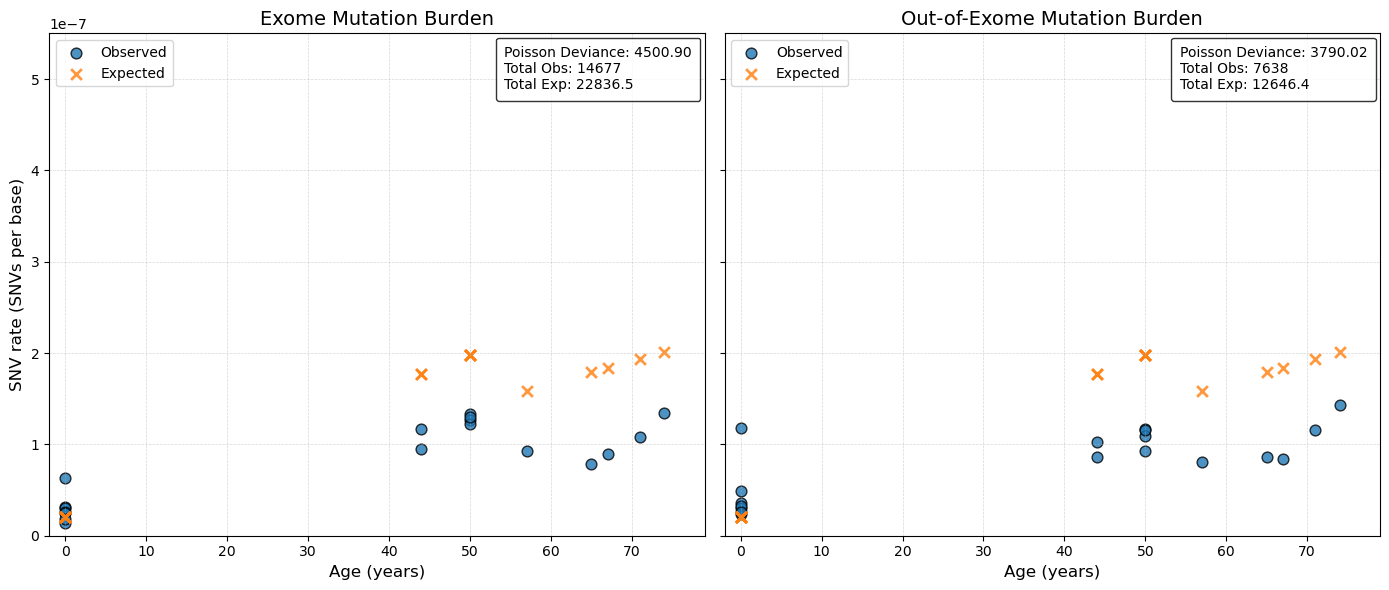

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import gzip
import bisect
from matplotlib.offsetbox import AnchoredText

# -----------------------
# Configuration
# -----------------------
METADATA_CSV = "testing_complete_processed_metadata.csv"
OUT_DIR = "CUH832_results"
OUTPUT_PNG = os.path.join(OUT_DIR, "test_exome_vs_out_plot.png")

# CRITICAL: Point this to your Whole Exome bed file so we can count WES variants
EXOME_BED_PATH = "../../resources/hg38_exome_v2.0.2_targets_sorted_validated.re_annotated.bed" 

GENOME_SIZE = 6.4e9
R_CORD = 2e-8
EPS = 1e-15

# -----------------------
# Bed Lookup Class
# -----------------------
class BedLookup:
    def __init__(self, bed_path, name):
        self.intervals = {} 
        self.name = name
        self._load_bed(bed_path)

    def _load_bed(self, bed_path):
        if not os.path.exists(bed_path):
            print(f"[WARN] BED file not found: {bed_path}. {self.name} filter will do nothing.")
            return

        count = 0
        with open(bed_path, 'r') as f:
            for line in f:
                if line.startswith('#') or not line.strip():
                    continue
                parts = line.strip().split()
                if len(parts) < 3:
                    continue
                chrom = parts[0]
                start, end = int(parts[1]), int(parts[2])
                
                if chrom not in self.intervals:
                    self.intervals[chrom] = []
                self.intervals[chrom].append((start, end))
                count += 1
        
        for chrom in self.intervals:
            self.intervals[chrom].sort(key=lambda x: x[0])
        print(f"[INFO] Loaded {count} regions for {self.name}.")

    def is_overlapped(self, chrom, pos):
        if chrom in self.intervals: regions = self.intervals[chrom]
        elif f"chr{chrom}" in self.intervals: regions = self.intervals[f"chr{chrom}"]
        elif chrom.startswith("chr") and chrom[3:] in self.intervals: regions = self.intervals[chrom[3:]]
        else: return False
        
        query_idx = pos - 1 
        idx = bisect.bisect_right(regions, (query_idx, float('inf')))
        
        for i in range(max(0, idx - 1), -1, -1):
            start, end = regions[i]
            if end <= query_idx: break 
            if start <= query_idx < end: return True
        return False

# -----------------------
# Helper Functions
# -----------------------
def poisson_deviance(y_arr, lam_arr):
    y = np.asarray(y_arr, dtype=float)
    lam = np.asarray(lam_arr, dtype=float) + EPS
    with np.errstate(divide='ignore', invalid='ignore'):
        log_term = np.log(y / lam)
        term1 = np.where(y > 0, y * log_term, 0.0)
    dev = 2.0 * (term1 - (y - lam))
    return float(np.sum(dev))

def get_expected_rate(sample_type, age):
    st = sample_type.lower() if isinstance(sample_type, str) else "t_cells"
    age = float(age) if pd.notna(age) else 0.0
    if "cord" in st: return R_CORD
    elif "pbmc" in st: return (16 * age + 105) / GENOME_SIZE
    else: return (22 * age + 164) / GENOME_SIZE

# -----------------------
# Main Execution
# -----------------------
if not os.path.exists(METADATA_CSV):
    print(f"[ERROR] Could not find {METADATA_CSV}.")
else:
    df_samples = pd.read_csv(METADATA_CSV)
    exome_lookup = BedLookup(EXOME_BED_PATH, "Exome Target BED")

    ages = []
    
    # Exome tracking
    obs_wes_list, exp_wes_list, bases_wes_list = [], [], []
    
    # Out of exome tracking
    obs_out_list, exp_out_list, bases_out_list = [], [], []

    print("[INFO] Intersecting filtered VCFs with WES boundaries...")
    for idx, s in df_samples.iterrows():
        # Get bases calculation
        b_wes = float(s["callable_sequenced_bases_wes"])
        b_pad = float(s["callable_sequenced_bases_padded"])
        b_out = b_pad - b_wes
        
        # Expected calculation
        age = float(s.age) if "age" in s else 0.0
        st = s.sample_type if "sample_type" in s else "T_cells"
        exp_rate = get_expected_rate(st, age)
        
        e_wes = exp_rate * b_wes
        e_out = exp_rate * b_out
        
        # Find the filtered VCF
        input_basename = os.path.basename(s.vcf_path).replace(".vcf", "").replace(".gz", "")
        filt_vcf = os.path.join(OUT_DIR, f"{s.sample_id}_{input_basename}.filtered.vcf")
        
        # fallback to .gz if standard uncompressed not found
        if not os.path.exists(filt_vcf) and os.path.exists(filt_vcf + ".gz"):
            filt_vcf += ".gz"

        o_wes = 0
        o_tot = 0
        
        if os.path.exists(filt_vcf):
            openf = gzip.open if filt_vcf.endswith(".gz") else open
            with openf(filt_vcf, "rt") as f:
                for line in f:
                    if line.startswith("#"): continue
                    fields = line.strip().split("\t")
                    if len(fields) < 2: continue
                    chrom = fields[0]
                    pos = int(fields[1])
                    o_tot += 1
                    
                    if exome_lookup.is_overlapped(chrom, pos):
                        o_wes += 1
                        
        o_out = o_tot - o_wes
        
        ages.append(age)
        obs_wes_list.append(o_wes)
        exp_wes_list.append(e_wes)
        bases_wes_list.append(b_wes)
        
        obs_out_list.append(o_out)
        exp_out_list.append(e_out)
        bases_out_list.append(b_out)

    # Convert to numpy arrays
    ages = np.array(ages)
    b_wes = np.array(bases_wes_list)
    b_out = np.array(bases_out_list)
    
    obs_rate_wes = np.array(obs_wes_list) / b_wes
    exp_rate_wes = np.array(exp_wes_list) / b_wes
    obs_rate_out = np.array(obs_out_list) / b_out
    exp_rate_out = np.array(exp_out_list) / b_out

    dev_wes = poisson_deviance(obs_wes_list, exp_wes_list)
    dev_out = poisson_deviance(obs_out_list, exp_out_list)

    # -----------------------
    # Plotting
    # -----------------------
    print("[INFO] Generating plots...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    valid_ages = ages[~np.isnan(ages)]
    x_min = min(valid_ages) - 2 if len(valid_ages) > 0 else -2
    x_max = max(valid_ages) + 5 if len(valid_ages) > 0 else 100

    # Panel 1: In Exome
    ax1 = axes[0]
    ax1.scatter(ages, obs_rate_wes, label="Observed", color="#1f77b4", alpha=0.8, marker="o", s=60, edgecolors='k')
    ax1.scatter(ages, exp_rate_wes, label="Expected", color="#ff7f0e", alpha=0.8, marker="x", s=60, linewidth=2)
    ax1.set_title("Exome Mutation Burden", fontsize=14)
    ax1.set_xlabel("Age (years)", fontsize=12)
    ax1.set_ylabel("SNV rate (SNVs per base)", fontsize=12)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(0, 5.5e-7)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

    stats_wes = (f"Poisson Deviance: {dev_wes:.2f}\n"
                 f"Total Obs: {int(np.sum(obs_wes_list))}\n"
                 f"Total Exp: {np.sum(exp_wes_list):.1f}")
    at1 = AnchoredText(stats_wes, prop=dict(size=10), frameon=True, loc='upper right')
    at1.patch.set_boxstyle("round,pad=0.2,rounding_size=0.2")
    at1.patch.set_alpha(0.8)
    ax1.add_artist(at1)
    ax1.legend(loc='upper left', frameon=True, fontsize=10)

    # Panel 2: Out of Exome
    ax2 = axes[1]
    ax2.scatter(ages, obs_rate_out, label="Observed", color="#1f77b4", alpha=0.8, marker="o", s=60, edgecolors='k')
    ax2.scatter(ages, exp_rate_out, label="Expected", color="#ff7f0e", alpha=0.8, marker="x", s=60, linewidth=2)
    ax2.set_title("Out-of-Exome Mutation Burden", fontsize=14)
    ax2.set_xlabel("Age (years)", fontsize=12)
    ax2.set_xlim(x_min, x_max)
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

    stats_out = (f"Poisson Deviance: {dev_out:.2f}\n"
                 f"Total Obs: {int(np.sum(obs_out_list))}\n"
                 f"Total Exp: {np.sum(exp_out_list):.1f}")
    at2 = AnchoredText(stats_out, prop=dict(size=10), frameon=True, loc='upper right')
    at2.patch.set_boxstyle("round,pad=0.2,rounding_size=0.2")
    at2.patch.set_alpha(0.8)
    ax2.add_artist(at2)
    ax2.legend(loc='upper left', frameon=True, fontsize=10)

    plt.tight_layout()
    plt.savefig(OUTPUT_PNG, dpi=150)
    print(f"[INFO] Plot saved to: {OUTPUT_PNG}")
    plt.show()

[INFO] Loading cached Test data from CUH832_results/test_exome_split_cache.csv
[INFO] Processing Train VCFs and splitting by WES boundaries. This may take a minute...

[INFO] Plot saved to: ./test_vs_train_exome_overlay_plot.png


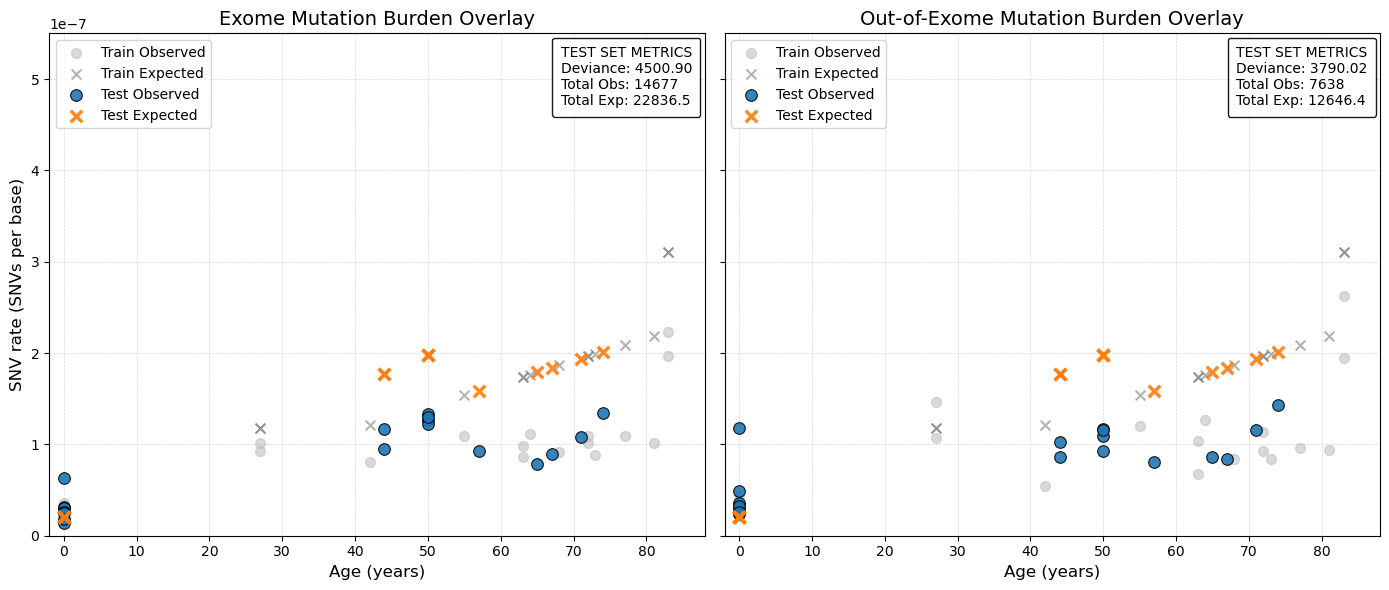

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import gzip
import bisect
from matplotlib.offsetbox import AnchoredText

# -----------------------
# Configuration
# -----------------------
# Input Metadata (Make sure paths are correct for both cohorts)
TEST_METADATA_CSV = "testing_complete_processed_metadata.csv"
TRAIN_METADATA_CSV = "training_processed_metadata.csv" 

# Directories containing the .filtered.vcf files
TEST_VCF_DIR = "CUH832_results"
TRAIN_VCF_DIR = "training_results"

# BED File
EXOME_BED_PATH = "../../resources/hg38_exome_v2.0.2_targets_sorted_validated.re_annotated.bed" 

# Cache paths (Saves the split counts so future plots are instant)
TEST_SPLIT_CACHE = os.path.join(TEST_VCF_DIR, "test_exome_split_cache.csv")
TRAIN_SPLIT_CACHE = os.path.join(TRAIN_VCF_DIR, "train_exome_split_cache.csv")

OUTPUT_PNG = "./test_vs_train_exome_overlay_plot.png"

# Constants
GENOME_SIZE = 6.4e9
R_CORD = 2e-8
EPS = 1e-15

# -----------------------
# Bed Lookup Class
# -----------------------
class BedLookup:
    def __init__(self, bed_path, name):
        self.intervals = {} 
        self.name = name
        self._load_bed(bed_path)

    def _load_bed(self, bed_path):
        if not os.path.exists(bed_path):
            print(f"[WARN] BED file not found: {bed_path}. Skipping intersection.")
            return

        with open(bed_path, 'r') as f:
            for line in f:
                if line.startswith('#') or not line.strip(): continue
                parts = line.strip().split()
                if len(parts) < 3: continue
                chrom = parts[0]
                start, end = int(parts[1]), int(parts[2])
                
                if chrom not in self.intervals:
                    self.intervals[chrom] = []
                self.intervals[chrom].append((start, end))
        
        for chrom in self.intervals:
            self.intervals[chrom].sort(key=lambda x: x[0])

    def is_overlapped(self, chrom, pos):
        if not self.intervals: return False
        if chrom in self.intervals: regions = self.intervals[chrom]
        elif f"chr{chrom}" in self.intervals: regions = self.intervals[f"chr{chrom}"]
        elif chrom.startswith("chr") and chrom[3:] in self.intervals: regions = self.intervals[chrom[3:]]
        else: return False
        
        query_idx = pos - 1 
        idx = bisect.bisect_right(regions, (query_idx, float('inf')))
        
        for i in range(max(0, idx - 1), -1, -1):
            start, end = regions[i]
            if end <= query_idx: break 
            if start <= query_idx < end: return True
        return False

# -----------------------
# Helper Functions
# -----------------------
def poisson_deviance(y_arr, lam_arr):
    y = np.asarray(y_arr, dtype=float)
    lam = np.asarray(lam_arr, dtype=float) + EPS
    with np.errstate(divide='ignore', invalid='ignore'):
        log_term = np.log(y / lam)
        term1 = np.where(y > 0, y * log_term, 0.0)
    dev = 2.0 * (term1 - (y - lam))
    return float(np.sum(dev))

def get_expected_rate(sample_type, age):
    st = str(sample_type).lower() if pd.notna(sample_type) else "t_cells"
    age = float(age) if pd.notna(age) else 0.0
    if "cord" in st: return R_CORD
    elif "pbmc" in st: return (16 * age + 105) / GENOME_SIZE
    else: return (22 * age + 164) / GENOME_SIZE

def process_cohort(metadata_csv, vcf_dir, cache_path, exome_lookup, cohort_name):
    """Reads metadata, intersects VCFs with BED, calculates expected, and caches results."""
    if os.path.exists(cache_path):
        print(f"[INFO] Loading cached {cohort_name} data from {cache_path}")
        return pd.read_csv(cache_path)

    if not os.path.exists(metadata_csv):
        print(f"[WARN] Metadata not found for {cohort_name}: {metadata_csv}")
        return pd.DataFrame()

    print(f"[INFO] Processing {cohort_name} VCFs and splitting by WES boundaries. This may take a minute...")
    df_samples = pd.read_csv(metadata_csv)
    results = []

    for idx, s in df_samples.iterrows():
        b_wes = float(s["callable_sequenced_bases_wes"])
        b_pad = float(s["callable_sequenced_bases_padded"])
        b_out = b_pad - b_wes
        
        age = float(s.age) if "age" in s else 0.0
        st = s.sample_type if "sample_type" in s else "T_cells"
        exp_rate = get_expected_rate(st, age)
        
        e_wes = exp_rate * b_wes
        e_out = exp_rate * b_out
        
        input_basename = os.path.basename(s.vcf_path).replace(".vcf", "").replace(".gz", "")
        filt_vcf = os.path.join(vcf_dir, f"{s.sample_id}_{input_basename}.filtered.vcf")
        if not os.path.exists(filt_vcf) and os.path.exists(filt_vcf + ".gz"):
            filt_vcf += ".gz"

        o_wes, o_tot = 0, 0
        if os.path.exists(filt_vcf):
            openf = gzip.open if filt_vcf.endswith(".gz") else open
            with openf(filt_vcf, "rt") as f:
                for line in f:
                    if line.startswith("#"): continue
                    fields = line.strip().split("\t")
                    if len(fields) < 2: continue
                    chrom, pos = fields[0], int(fields[1])
                    o_tot += 1
                    if exome_lookup.is_overlapped(chrom, pos):
                        o_wes += 1
                        
        o_out = o_tot - o_wes
        
        results.append({
            "sample_id": s.sample_id, "age": age,
            "obs_wes": o_wes, "exp_wes": e_wes, "bases_wes": b_wes,
            "obs_out": o_out, "exp_out": e_out, "bases_out": b_out
        })

    df_results = pd.DataFrame(results)
    df_results.to_csv(cache_path, index=False)
    return df_results

# -----------------------
# Data Processing
# -----------------------
exome_lookup = BedLookup(EXOME_BED_PATH, "Exome Target BED")

test_df = process_cohort(TEST_METADATA_CSV, TEST_VCF_DIR, TEST_SPLIT_CACHE, exome_lookup, "Test")
train_df = process_cohort(TRAIN_METADATA_CSV, TRAIN_VCF_DIR, TRAIN_SPLIT_CACHE, exome_lookup, "Train")

# Calculate Deviance for Test Set (for the text boxes)
if not test_df.empty:
    dev_wes = poisson_deviance(test_df["obs_wes"], test_df["exp_wes"])
    dev_out = poisson_deviance(test_df["obs_out"], test_df["exp_out"])
else:
    dev_wes = dev_out = 0.0

# -----------------------
# Plotting
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Helper function to plot overlay
def plot_overlay(ax, train_data, test_data, obs_col, exp_col, bases_col, title, test_dev):
    # Plot Train (Grey / Background)
    if not train_data.empty:
        t_ages = train_data["age"].values
        t_obs_rate = train_data[obs_col].values / (train_data[bases_col].values + EPS)
        t_exp_rate = train_data[exp_col].values / (train_data[bases_col].values + EPS)
        
        ax.scatter(t_ages, t_obs_rate, label="Train Observed", color="silver", alpha=0.6, marker="o", s=50, zorder=1)
        ax.scatter(t_ages, t_exp_rate, label="Train Expected", color="grey", alpha=0.6, marker="x", s=50, zorder=1)

    # Plot Test (Color / Foreground)
    if not test_data.empty:
        te_ages = test_data["age"].values
        te_obs_rate = test_data[obs_col].values / (test_data[bases_col].values + EPS)
        te_exp_rate = test_data[exp_col].values / (test_data[bases_col].values + EPS)

        ax.scatter(te_ages, te_obs_rate, label="Test Observed", color="#1f77b4", alpha=0.9, marker="o", s=70, edgecolors='k', linewidth=0.8, zorder=2)
        ax.scatter(te_ages, te_exp_rate, label="Test Expected", color="#ff7f0e", alpha=0.9, marker="x", s=70, linewidth=2.5, zorder=2)
        
        # Add Stats Box (Test Only)
        tot_obs = np.sum(test_data[obs_col])
        tot_exp = np.sum(test_data[exp_col])
        stats_text = (f"TEST SET METRICS\n"
                      f"Deviance: {test_dev:.2f}\n"
                      f"Total Obs: {int(tot_obs)}\n"
                      f"Total Exp: {tot_exp:.1f}")
        at = AnchoredText(stats_text, prop=dict(size=10), frameon=True, loc='upper right')
        at.patch.set_boxstyle("round,pad=0.2,rounding_size=0.2")
        at.patch.set_alpha(0.9)
        at.patch.set_facecolor("white")
        ax.add_artist(at)

    # Styling
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Age (years)", fontsize=12)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.legend(loc='upper left', frameon=True, fontsize=10)

# Apply limits
all_ages = np.concatenate([test_df["age"].values if not test_df.empty else [],
                           train_df["age"].values if not train_df.empty else []])
valid_ages = all_ages[~np.isnan(all_ages)]
x_min, x_max = (min(valid_ages) - 2, max(valid_ages) + 5) if len(valid_ages) > 0 else (-2, 100)

# Panel 1: Exome
plot_overlay(axes[0], train_df, test_df, "obs_wes", "exp_wes", "bases_wes", "Exome Mutation Burden Overlay", dev_wes)
axes[0].set_ylabel("SNV rate (SNVs per base)", fontsize=12)
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(0, 5.5e-7)

# Panel 2: Out of Exome
plot_overlay(axes[1], train_df, test_df, "obs_out", "exp_out", "bases_out", "Out-of-Exome Mutation Burden Overlay", dev_out)
axes[1].set_xlim(x_min, x_max)

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150)
print(f"\n[INFO] Plot saved to: {OUTPUT_PNG}")
plt.show()

----------------------------------------
[INFO] Train Cord (Exome):    2.85e-08 (Obs: 747)
[INFO] Train Cord (Out):      3.78e-08 (Obs: 512)
[INFO] Test Cord (Exome):     2.78e-08 (Obs: 1586)
[INFO] Test Cord (Out):       3.79e-08 (Obs: 1160)
[INFO] Reference Rate:        2.00e-08
[INFO] Plot saved to:         ./cord_blood_snv_exome_comparison.png
----------------------------------------


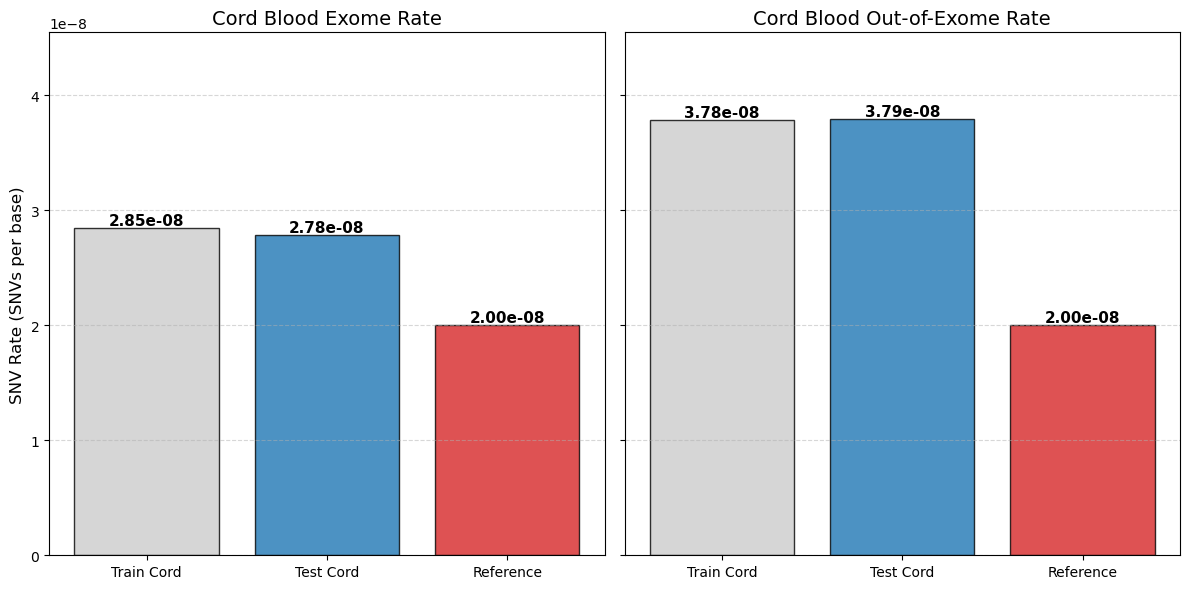

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------
# Configuration
# -----------------------
# Use the cache files generated by the previous split script
TRAIN_CACHE = "training_results/train_exome_split_cache.csv"
TEST_CACHE = "CUH832_results/test_exome_split_cache.csv"
OUTPUT_PNG = "./cord_blood_snv_exome_comparison.png"

REFERENCE_RATE = 2e-8

def get_cord_blood_split_rates(csv_path):
    """
    Loads split cache CSV, filters for age == 0 (Cord Blood), 
    and calculates aggregate SNV rates for Exome and Out-of-Exome.
    """
    if not os.path.exists(csv_path):
        print(f"[WARNING] File not found: {csv_path}. Did you run the split script first?")
        return 0.0, 0, 0.0, 0
        
    df = pd.read_csv(csv_path)
    
    # Filter for Cord Blood (Age = 0)
    cord_data = df[np.isclose(df["age"], 0, atol=1e-5)]
    
    if cord_data.empty:
        print(f"[WARNING] No Cord Blood (age=0) data found in {csv_path}")
        return 0.0, 0, 0.0, 0
    
    # Exome (WES) totals
    obs_wes = cord_data["obs_wes"].sum()
    bases_wes = cord_data["bases_wes"].sum()
    rate_wes = obs_wes / bases_wes if bases_wes > 0 else 0.0
    
    # Out-of-Exome totals
    obs_out = cord_data["obs_out"].sum()
    bases_out = cord_data["bases_out"].sum()
    rate_out = obs_out / bases_out if bases_out > 0 else 0.0
        
    return rate_wes, obs_wes, rate_out, obs_out

# -----------------------
# Main Execution
# -----------------------
# 1. Get Rates
train_rate_wes, train_obs_wes, train_rate_out, train_obs_out = get_cord_blood_split_rates(TRAIN_CACHE)
test_rate_wes, test_obs_wes, test_rate_out, test_obs_out = get_cord_blood_split_rates(TEST_CACHE)

# 2. Prepare Data for Plotting
labels = ['Train Cord', 'Test Cord', 'Reference']
colors = ['#cccccc', '#1f77b4', '#d62728']  # Grey, Blue, Red

rates_wes = [train_rate_wes, test_rate_wes, REFERENCE_RATE]
rates_out = [train_rate_out, test_rate_out, REFERENCE_RATE]

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Function to style and label bars
def plot_bars(ax, rates, title):
    bars = ax.bar(labels, rates, color=colors, edgecolor='k', alpha=0.8)
    ax.set_title(title, fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2e}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    return bars

# Panel 1: Exome
plot_bars(axes[0], rates_wes, "Cord Blood Exome Rate")
axes[0].set_ylabel("SNV Rate (SNVs per base)", fontsize=12)

# Panel 2: Out of Exome
plot_bars(axes[1], rates_out, "Cord Blood Out-of-Exome Rate")

# Adjust Y-limit to fit labels
max_rate = max(max(rates_wes), max(rates_out))
axes[0].set_ylim(0, max_rate * 1.2)

plt.tight_layout()

# 4. Save and Show
plt.savefig(OUTPUT_PNG, dpi=150)

print("-" * 40)
print(f"[INFO] Train Cord (Exome):    {train_rate_wes:.2e} (Obs: {int(train_obs_wes)})")
print(f"[INFO] Train Cord (Out):      {train_rate_out:.2e} (Obs: {int(train_obs_out)})")
print(f"[INFO] Test Cord (Exome):     {test_rate_wes:.2e} (Obs: {int(test_obs_wes)})")
print(f"[INFO] Test Cord (Out):       {test_rate_out:.2e} (Obs: {int(test_obs_out)})")
print(f"[INFO] Reference Rate:        {REFERENCE_RATE:.2e}")
print(f"[INFO] Plot saved to:         {OUTPUT_PNG}")
print("-" * 40)

plt.show()